# Term Project - Driver Baheviour Classification

***Objective***

The primary objective of this project is to develop a deep learning-based image classification model that can automatically detect and classify different driver behaviors. The system aims to distinguish between safe driving and various distracted behaviors such as texting, calling, or turning away from the road.

By leveraging Convolutional Neural Networks (CNNs) like VGG16, MobileNet and AlexNet, the model learns visual patterns associated with each behavior category. The goal is to achieve high classification accuracy and reliable real-time performance.


In [ ]:
# importing necessary libraries

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

import kagglehub
from pathlib import Path
import hashlib
import cv2
from PIL import Image



In [ ]:
!pip install kaggle

### Data Reading from kaggle

In [53]:
path = kagglehub.dataset_download("robinreni/revitsone-5class")

print("Path to dataset files:", path)

100%|██████████| 983M/983M [00:15<00:00, 68.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1


In [54]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [55]:

dataset_path = "/root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes"
dataset_path = Path(dataset_path)
for folder in os.listdir(dataset_path):
    print(folder)

safe_driving
other_activities
talking_phone
turning
texting_phone


In [77]:
# Create a dataset from the image folders
data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=(256, 256),
    batch_size=32
)

class_names = data.class_names
print("Classes:", class_names)

Found 10766 files belonging to 5 classes.
Classes: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


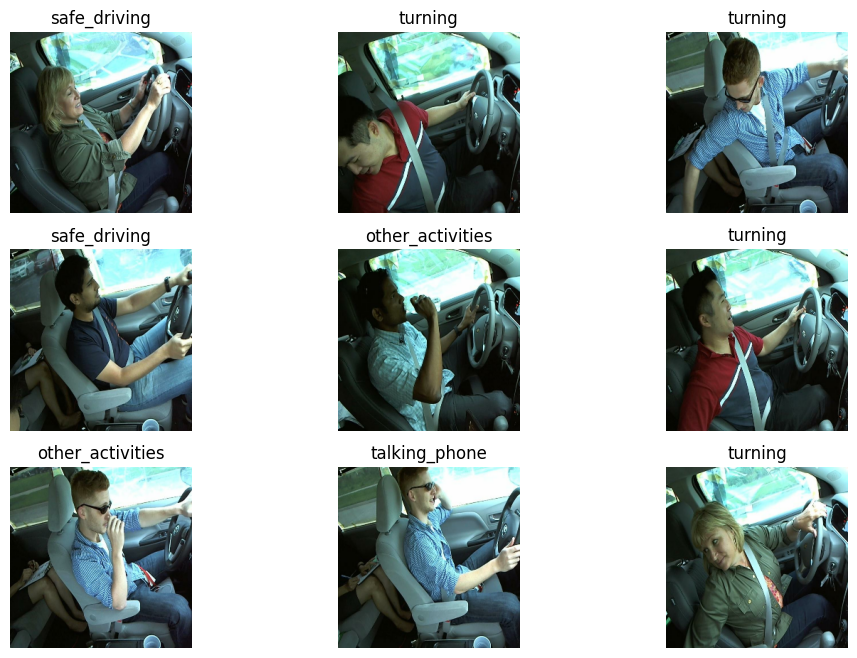

In [78]:

plt.figure(figsize=(12,8))
for images_batch, labels_batch in data.take(10):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images_batch[i].numpy().astype("uint8"))
        plt.title(class_names[labels_batch[i]])
        plt.axis("off")

## Dataset Preparation

The dataset consists of five image classes stored in separate folders.
Each folder represents one class label.

Before training, the dataset was cleaned by verifying all image files using PIL.
Corrupted or unreadable images were removed to prevent runtime decoding errors
during model training.

The dataset was then split using stratified sampling into:

- 70% Training set
- 10% Validation set
- 20% Test set

Stratification ensures that each split maintains the same class distribution.
The test set was kept completely unseen during training and model selection.

### Checking for duplicates

In [79]:
def get_file_hash(filepath):
  hash_md5 = hashlib.md5()
  with open(filepath, "rb") as f:
       for chunk in iter(lambda: f.read(4096), b""):
            hash_md5.update(chunk)
  return hash_md5.hexdigest()

hashes = {}
duplicates = []
total_images = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            total_images += 1
            filepath = os.path.join(root, file)
            file_hash = get_file_hash(filepath)

            if file_hash in hashes:
                duplicates.append((filepath, hashes[file_hash]))
            else:
                hashes[file_hash] = filepath

print("Total images:", total_images)
print("Number of duplicate images:", len(duplicates))
print("Number of hashes images:", len(hashes))


Total images: 10766
Number of duplicate images: 0
Number of hashes images: 10766


### Checking for unreadable images

In [80]:
bad_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepath = os.path.join(root, file)
            img = cv2.imread(filepath)
            if img is None:
                bad_files.append(filepath)

print("Unreadable images:", len(bad_files))

Unreadable images: 15


In [81]:
for file in bad_files[:5]:   # show first 5
    try:
        img = Image.open(file)
        plt.imshow(img)
        plt.title("Corrupted Image")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print("Cannot display:", file)
        print("Error:", e)


Cannot display: /root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_22266.jpg
Error: cannot identify image file '/root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_22266.jpg'
Cannot display: /root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_79.jpg
Error: cannot identify image file '/root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_79.jpg'
Cannot display: /root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_13625.jpg
Error: cannot identify image file '/root/.cache/kagglehub/datasets/robinreni/revitsone-5class/versions/1/revitsone-5classes/Revitsone-5classes/other_activities/img_13625.jpg'
Cannot display: 

In [82]:
for file in bad_files:
    os.remove(file)

print("Corrupted images removed.")

Corrupted images removed.


In [83]:
labels = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
num_classes = len(labels)

class_to_id = {name: idx for idx, name in enumerate(labels)}
class_to_id

{'other_activities': 0,
 'safe_driving': 1,
 'talking_phone': 2,
 'texting_phone': 3,
 'turning': 4}

In [84]:
all_files = []
all_labels = []

for cname in labels:
    class_dir = dataset_path / cname
    files = [
        str(f) for f in class_dir.glob("*")
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    all_files.extend(files)
    all_labels.extend([class_to_id[cname]] * len(files))

all_files = np.array(all_files)
all_labels = np.array(all_labels)

print("Total images:", len(all_files))

Total images: 10751


In [85]:
import os, random
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [86]:
# Test split (20%)
x_trainval, x_test, y_trainval, y_test = train_test_split(
    all_files,
    all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=SEED
)

# Validation split (10% of total = 12.5% of trainval)
x_train, x_val, y_train, y_val = train_test_split(
    x_trainval,
    y_trainval,
    test_size=0.125,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Train: {len(x_train)} ({len(x_train)/len(all_files):.2%})")
print(f"Val:   {len(x_val)} ({len(x_val)/len(all_files):.2%})")
print(f"Test:  {len(x_test)} ({len(x_test)/len(all_files):.2%})")


Train: 7525 (69.99%)
Val:   1075 (10.00%)
Test:  2151 (20.01%)


In [87]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [88]:
# Image loader
def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # baseline normalization
    return img, label

In [89]:
# Dataset builder

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [90]:
# Create datasets
train_ds = make_ds(x_train, y_train, training=True)
val_ds   = make_ds(x_val, y_val)
test_ds  = make_ds(x_test, y_test)

# Baseline CNN

## Baseline Convolutional Neural Network (CNN)

A simple CNN was implemented as a baseline model.
This model was trained from scratch without any pretrained weights.

Architecture:
- 3 Convolutional blocks (Conv + BatchNorm + ReLU + MaxPooling)
- Global Average Pooling
- Dense layer with Dropout
- Softmax output layer

Images were normalized by scaling pixel values to the range [0,1].

The purpose of this baseline model is to evaluate performance without
transfer learning and to serve as a comparison benchmark for pretrained models.

In [91]:
baseline_model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),  # better than Flatten
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])


In [92]:
baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

In [93]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


In [94]:
EPOCHS = 10

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[callback]
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.2518 - loss: 1.6257 - val_accuracy: 0.2037 - val_loss: 1.7444
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.3662 - loss: 1.4624 - val_accuracy: 0.2056 - val_loss: 1.8560
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.4381 - loss: 1.3145 - val_accuracy: 0.2781 - val_loss: 1.4872
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.4803 - loss: 1.2186 - val_accuracy: 0.4856 - val_loss: 1.1895
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.5225 - loss: 1.1248 - val_accuracy: 0.3647 - val_loss: 2.3414
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.5594 - loss: 1.0574 - val_accuracy: 0.1935 - val_loss: 4.2564


In [95]:
test_loss, test_acc = baseline_model.evaluate(test_ds)
print(f"Baseline Test Accuracy: {test_acc:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.4939 - loss: 1.1752
Baseline Test Accuracy: 0.4993


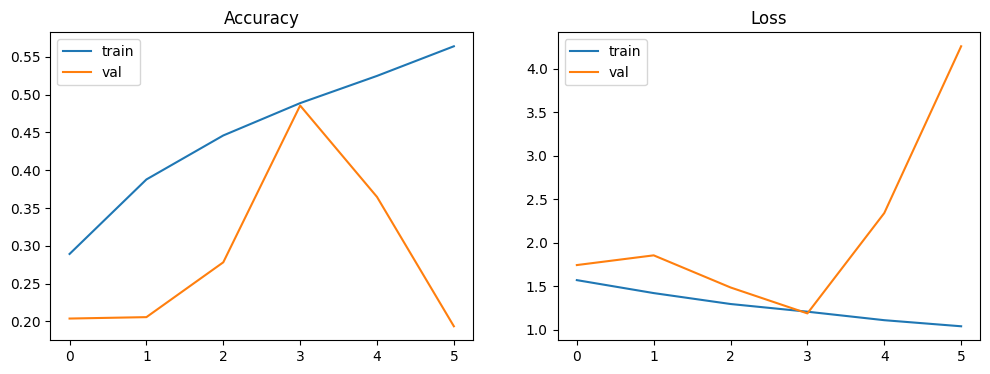

In [96]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()


## VGG16 Transfer Learning

To improve performance, transfer learning was applied using the pretrained
VGG16 model trained on ImageNet.

Two training phases were used:

1. Feature Extraction:
   - The convolutional base was frozen.
   - Only the custom classification head was trained.

2. Fine-Tuning:
   - The deeper convolutional layers were unfrozen.
   - A smaller learning rate was used.
   - This allowed the model to adapt pretrained features to the target dataset.

VGG16-specific preprocessing was applied to match ImageNet training conditions.

In [97]:
from tensorflow.keras.applications.vgg16 import preprocess_input

def decode_and_resize_vgg(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)   # VGG16 preprocessing
    return img, label


In [98]:
def make_ds_vgg(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(decode_and_resize_vgg, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds_vgg = make_ds_vgg(x_train, y_train, training=True)
val_ds_vgg   = make_ds_vgg(x_val, y_val)
test_ds_vgg  = make_ds_vgg(x_test, y_test)

Load VGG16 backbone (frozen)

In [99]:
from tensorflow.keras.applications import VGG16
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

vgg_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [100]:
vgg_model = models.Sequential([
    vgg_base,

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation="softmax")
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [101]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]


In [102]:
vgg_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,301 (56.64 MB)

 Trainable params: 132,613 (518.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [103]:
EPOCHS = 10

history_vgg = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 92s 314ms/step - accuracy: 0.2583 - loss: 5.3534 - val_accuracy: 0.5237 - val_loss: 1.1615
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 56s 237ms/step - accuracy: 0.4574 - loss: 1.4882 - val_accuracy: 0.6940 - val_loss: 0.8883
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 56s 236ms/step - accuracy: 0.5655 - loss: 1.1256 - val_accuracy: 0.7795 - val_loss: 0.7272
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 55s 233ms/step - accuracy: 0.6442 - loss: 0.9146 - val_accuracy: 0.8279 - val_loss: 0.6010
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 56s 235ms/step - accuracy: 0.7163 - loss: 0.7783 - val_accuracy: 0.8558 - val_loss: 0.5045
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 84s 245ms/step - accuracy: 0.7627 - loss: 0.6535 - val_accuracy: 0.8837 - val_loss: 0.4391
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 81s 243ms/step - accuracy: 0.7816 - loss: 0.5975 - val_accuracy: 0.9060 - val_loss: 0.3839
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 56s 235ms/step - accuracy: 0.8129 - loss: 0

In [104]:
test_loss, test_acc = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 Test Accuracy: {test_acc:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 278ms/step - accuracy: 0.9354 - loss: 0.2753
VGG16 Test Accuracy: 0.9340


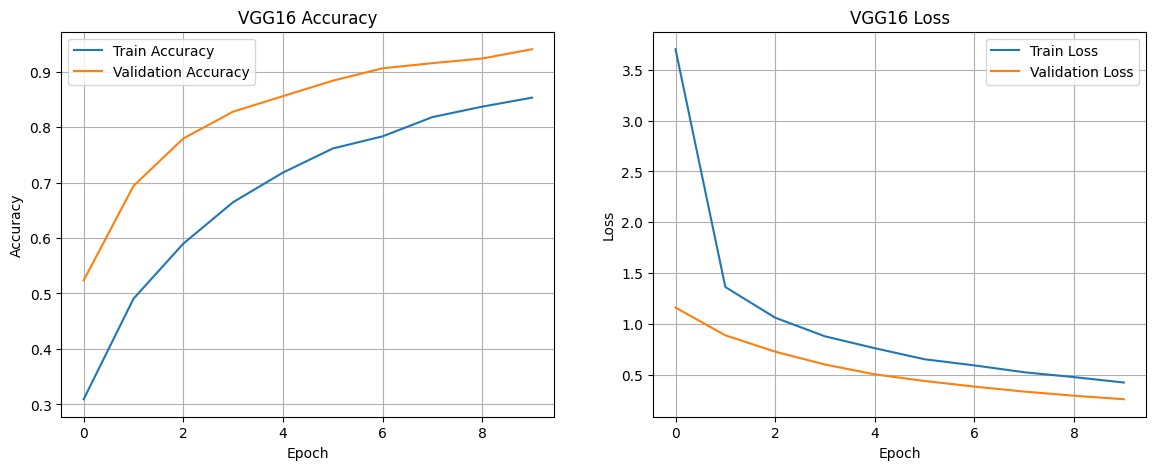

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
ax[0].plot(history_vgg.history['accuracy'], label='Train Accuracy')
ax[0].plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('VGG16 Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

# Loss
ax[1].plot(history_vgg.history['loss'], label='Train Loss')
ax[1].plot(history_vgg.history['val_loss'], label='Validation Loss')
ax[1].set_title('VGG16 Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.show()


### Fine-tuning

In [106]:
vgg_base.trainable = True

# Freeze first 3 blocks
for layer in vgg_base.layers[:15]:
    layer.trainable = False

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [107]:
history_finetune = vgg_model.fit(
    train_ds_vgg,
    validation_data=val_ds_vgg,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 76s 294ms/step - accuracy: 0.8672 - loss: 0.3708 - val_accuracy: 0.9600 - val_loss: 0.1392
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 65s 275ms/step - accuracy: 0.9388 - loss: 0.1833 - val_accuracy: 0.9823 - val_loss: 0.0748
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 86s 294ms/step - accuracy: 0.9591 - loss: 0.1148 - val_accuracy: 0.9860 - val_loss: 0.0612
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 66s 278ms/step - accuracy: 0.9747 - loss: 0.0807 - val_accuracy: 0.9860 - val_loss: 0.0566
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 64s 273ms/step - accuracy: 0.9773 - loss: 0.0676 - val_accuracy: 0.9879 - val_loss: 0.0502
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 65s 274ms/step - accuracy: 0.9835 - loss: 0.0457 - val_accuracy: 0.9907 - val_loss: 0.0497
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 65s 273ms/step - accuracy: 0.9848 - loss: 0.0399 - val_accuracy: 0.9870 - val_loss: 0.0482
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 83s 280ms/step - accuracy: 0.9917 - loss: 0

In [108]:
test_loss_ft, test_acc_ft = vgg_model.evaluate(test_ds_vgg)
print(f"VGG16 Fine-tuned Test Accuracy: {test_acc_ft:.4f}")
print(f"VGG16 Fine-tuned Test Loss: {test_loss_ft:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 216ms/step - accuracy: 0.9846 - loss: 0.0507
VGG16 Fine-tuned Test Accuracy: 0.9870
VGG16 Fine-tuned Test Loss: 0.0443


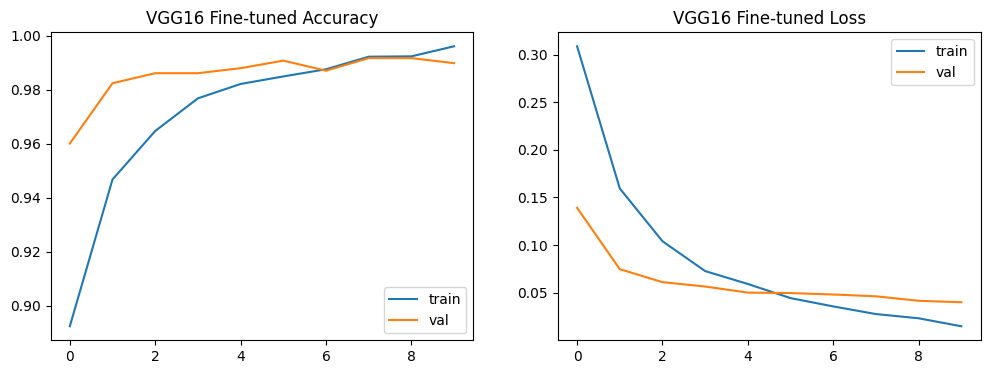

In [109]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_finetune.history['accuracy'], label='train')
plt.plot(history_finetune.history['val_accuracy'], label='val')
plt.title("VGG16 Fine-tuned Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_finetune.history['loss'], label='train')
plt.plot(history_finetune.history['val_loss'], label='val')
plt.title("VGG16 Fine-tuned Loss")
plt.legend()

plt.show()



## MobileNetV2 Transfer Learning

MobileNetV2, a lightweight architecture optimized for efficiency,
was also evaluated using transfer learning.

Similar to VGG16, the model was trained in two stages:
- Frozen feature extraction
- Fine-tuning with a lower learning rate

MobileNetV2 uses depthwise separable convolutions, which significantly
reduce the number of parameters compared to traditional CNN architectures.

In [110]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def decode_and_resize_mobilenet(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)  # scales to [-1, 1]
    return img, label

In [111]:
def make_ds_mobilenet(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.map(decode_and_resize_mobilenet, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds_m = make_ds_mobilenet(x_train, y_train, training=True)
val_ds_m   = make_ds_mobilenet(x_val, y_val)
test_ds_m  = make_ds_mobilenet(x_test, y_test)

### Load MobileNetV2 Backbone (Frozen First)

In [112]:
from tensorflow.keras.applications import MobileNetV2

mobilenet_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_base.trainable = False  # feature extraction first


In [113]:
mobilenet_model = tf.keras.Sequential([
    mobilenet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [114]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

history_mobilenet = mobilenet_model.fit(
    train_ds_m,
    validation_data=val_ds_m,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 51s 179ms/step - accuracy: 0.2796 - loss: 1.7081 - val_accuracy: 0.6688 - val_loss: 1.1424
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.5665 - loss: 1.1427 - val_accuracy: 0.7758 - val_loss: 0.8234
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.6911 - loss: 0.8790 - val_accuracy: 0.8270 - val_loss: 0.6582
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.7617 - loss: 0.7202 - val_accuracy: 0.8521 - val_loss: 0.5518
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.7995 - loss: 0.6317 - val_accuracy: 0.8726 - val_loss: 0.4841
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 69ms/step - accuracy: 0.8285 - loss: 0.5443 - val_accuracy: 0.8847 - val_loss: 0.4345
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8437 - loss: 0.4911 - val_accuracy: 0.9014 - val_loss: 0.3846
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.8628 - loss: 0.4339 -

Fine-tuning

In [115]:
# Unfreeze part of the model.

mobilenet_base.trainable = True

# Freeze first 100 layers (keep early features stable)
for layer in mobilenet_base.layers[:100]:
    layer.trainable = False

In [116]:
# Recompile with lower LR.

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [117]:
history_mobilenet_ft = mobilenet_model.fit(
    train_ds_m,
    validation_data=val_ds_m,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 58s 152ms/step - accuracy: 0.5326 - loss: 1.3840 - val_accuracy: 0.8819 - val_loss: 0.3691
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.8517 - loss: 0.4684 - val_accuracy: 0.9023 - val_loss: 0.2990
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9220 - loss: 0.2674 - val_accuracy: 0.9237 - val_loss: 0.2387
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.9504 - loss: 0.1742 - val_accuracy: 0.9423 - val_loss: 0.1815
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 75ms/step - accuracy: 0.9637 - loss: 0.1291 - val_accuracy: 0.9572 - val_loss: 0.1454
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.9734 - loss: 0.0990 - val_accuracy: 0.9628 - val_loss: 0.1149
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 75ms/step - accuracy: 0.9786 - loss: 0.0789 - val_accuracy: 0.9665 - val_loss: 0.1044
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 72ms/step - accuracy: 0.9887 - loss: 0.0533 -

In [118]:
test_loss_m, test_acc_m = mobilenet_model.evaluate(test_ds_m)
print(f"MobileNetV2 Test Accuracy: {test_acc_m:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 212ms/step - accuracy: 0.9840 - loss: 0.0669
MobileNetV2 Test Accuracy: 0.9814


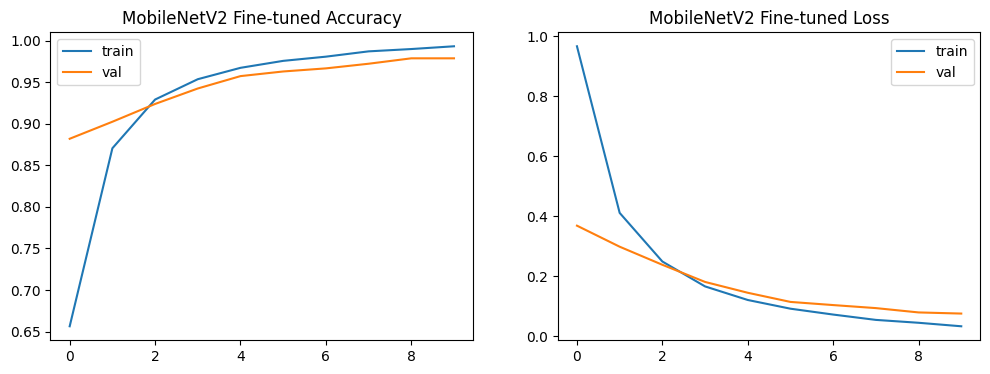

In [119]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_mobilenet_ft.history['accuracy'], label='train')
plt.plot(history_mobilenet_ft.history['val_accuracy'], label='val')
plt.title("MobileNetV2 Fine-tuned Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_mobilenet_ft.history['loss'], label='train')
plt.plot(history_mobilenet_ft.history['val_loss'], label='val')
plt.title("MobileNetV2 Fine-tuned Loss")
plt.legend()

plt.show()


## AlexNet

AlexNet is a deep learning model that made a big impact in image recognition. It became famous for its ability to classify images accurately. It won the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2012 with a top-5 error rate of 15.3% (beating the runner up which had a top-5 error rate of 26.2%).


**AlexNet Architecture**

Its architecture includes:

* 5 convolutional layers with Max-Pooling applied after the 1st, 2nd and 5th layers to enhance feature extraction.

* Overlapping Max-Pooling uses a 3×3 filter with stride 2 which improved performance by reducing top-1 error by 0.4% and top-5 error by 0.3% compared to non-overlapping pooling.

* Followed by 2 fully connected layers each using dropout to prevent overfitting.

* Ends with a softmax layer for final classification.

In [120]:
IMG_SIZE = (224, 224, 3)
NUM_CLASSES = 5

def AlexNet(input_shape=IMG_SIZE, num_classes=NUM_CLASSES):
    model = models.Sequential()

    # Conv Layer 1
    model.add(layers.Conv2D(96, kernel_size=11, strides=4, activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Conv Layer 2
    model.add(layers.Conv2D(256, kernel_size=5, padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Conv Layer 3
    model.add(layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'))

    # Conv Layer 4
    model.add(layers.Conv2D(384, kernel_size=3, padding='same', activation='relu'))

    # Conv Layer 5
    model.add(layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(pool_size=3, strides=2))

    # Flatten
    model.add(layers.Flatten())

    # Fully connected layers
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

model_Alex = AlexNet()
model_Alex.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,357,957 (43.33 MB)

 Trainable params: 11,357,253 (43.32 MB)

 Non-trainable params: 704 (2.75 KB)

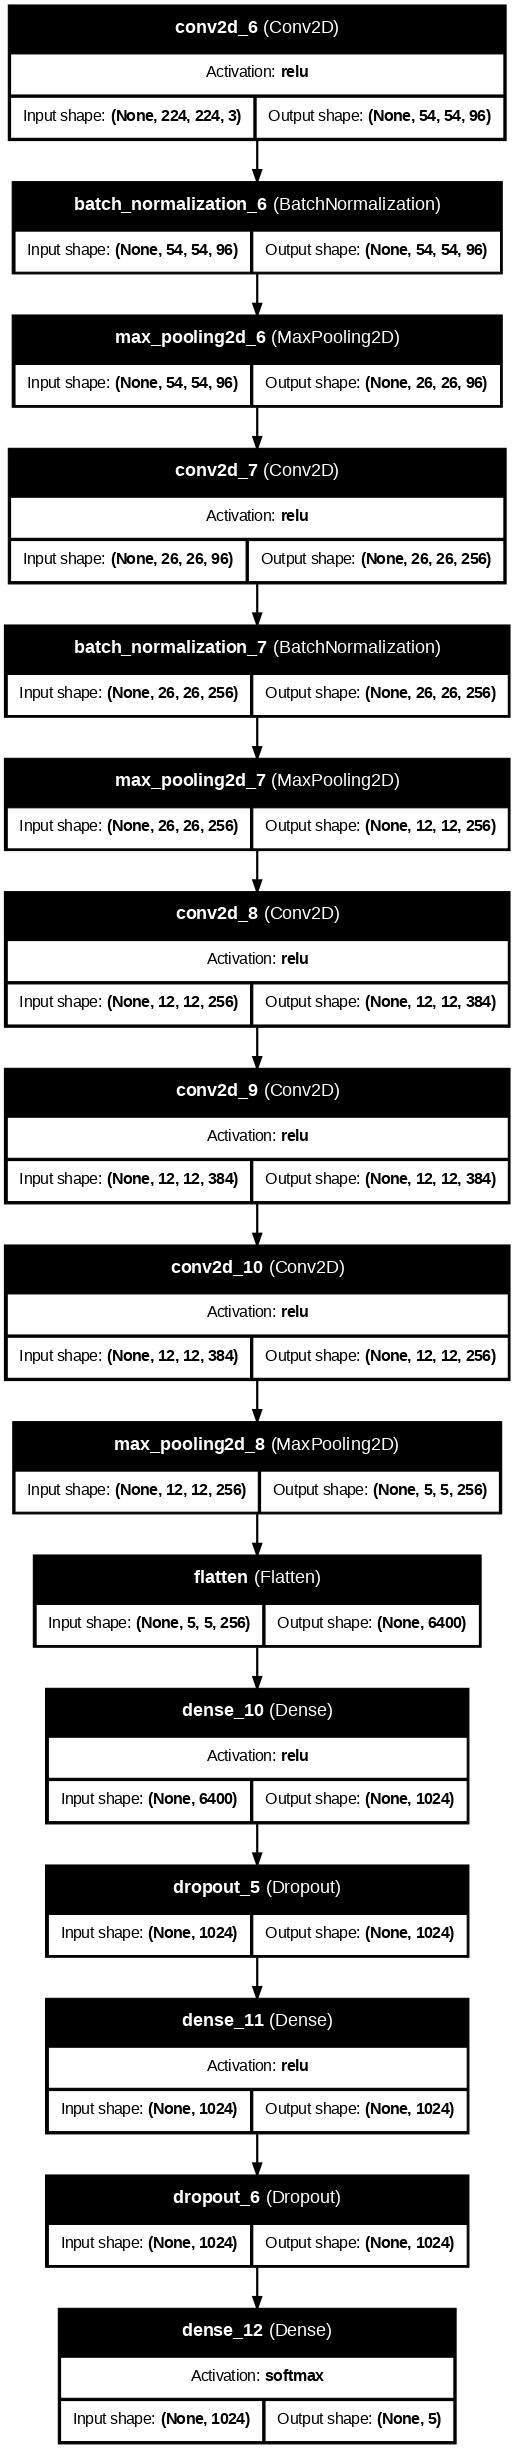

In [121]:
tf.keras.utils.plot_model(
    model_Alex,
    to_file='alex_model.png',
    show_shapes=True,
    show_layer_names=True,
    show_layer_activations=True,
    dpi=80
)

In [122]:
model_Alex.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

model_Alex.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 54, 54, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     6,554,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,357,957 (43.33 MB)

 Trainable params: 11,357,253 (43.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [123]:
history_alex = model_Alex.fit(train_ds,
                         epochs=20, validation_data = val_ds)

Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 35s 104ms/step - accuracy: 0.3053 - loss: 1.9136 - val_accuracy: 0.4512 - val_loss: 1.2126
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 69ms/step - accuracy: 0.6347 - loss: 0.8972 - val_accuracy: 0.7470 - val_loss: 0.6391
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.7993 - loss: 0.5413 - val_accuracy: 0.8233 - val_loss: 0.5131
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.8651 - loss: 0.3788 - val_accuracy: 0.9144 - val_loss: 0.3015
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.8972 - loss: 0.3075 - val_accuracy: 0.8967 - val_loss: 0.3854
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9160 - loss: 0.2484 - val_accuracy: 0.9237 - val_loss: 0.2405
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.9331 - loss: 0.1798 - val_accuracy: 0.9144 - val_loss: 0.2961
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.9420 - loss: 0.1805 -

Text(0.5, 1.0, 'Accuracy')

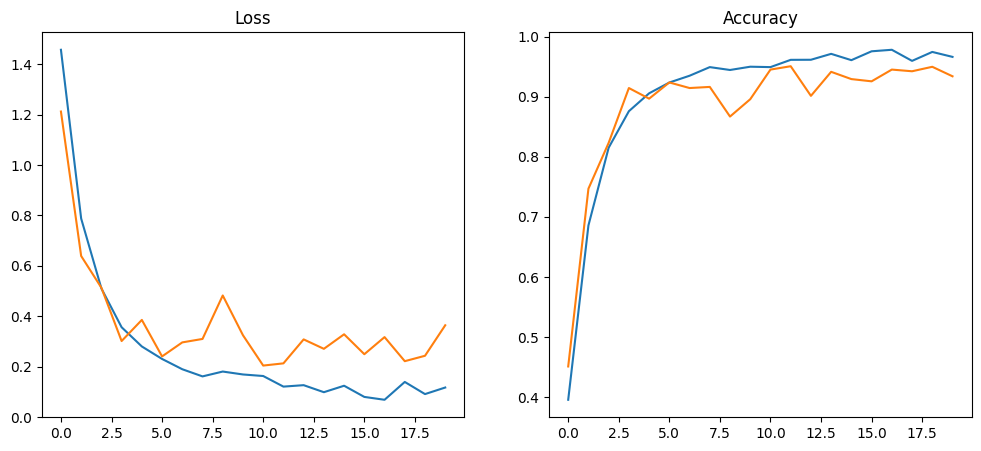

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_alex.history['loss'])
plt.plot(history_alex.history['val_loss'])
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_alex.history['accuracy'])
plt.plot(history_alex.history['val_accuracy'])
plt.title("Accuracy")

In [125]:
test_loss, test_acc = model_Alex.evaluate(test_ds)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step - accuracy: 0.9288 - loss: 0.2953
Test Accuracy: 0.9293
Test Loss: 0.3069


### All model's accuracy

In [126]:
# Baseline
test_loss_base, test_acc_base = baseline_model.evaluate(test_ds)
print(f" Baseline model: Test accuracy-{test_acc_base}, Test loss-{test_loss_base} ")

# VGG16
test_loss_vgg, test_acc_vgg = vgg_model.evaluate(test_ds_vgg)
print(f" VGG16 model: Test accuracy-{test_acc_vgg}, Test loss-{test_loss_vgg} ")

# MobileNet
test_loss_mob, test_acc_mob = mobilenet_model.evaluate(test_ds_m)
print(f" MobileNet model: Test accuracy-{test_acc_mob}, Test loss-{test_loss_mob} ")

# AlexNet
test_loss_alex, test_acc_alex = model_Alex.evaluate(test_ds)
print(f" AlexNet model: Test accuracy-{test_acc_alex}, Test loss-{test_loss_alex} ")

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4939 - loss: 1.1752
 Baseline model: Test accuracy-0.4993026554584503, Test loss-1.173715353012085 
68/68 ━━━━━━━━━━━━━━━━━━━━ 14s 206ms/step - accuracy: 0.9846 - loss: 0.0507
 VGG16 model: Test accuracy-0.9869828224182129, Test loss-0.044255468994379044 
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9840 - loss: 0.0669
 MobileNet model: Test accuracy-0.9814040064811707, Test loss-0.06717760115861893 
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.9288 - loss: 0.2953
 AlexNet model: Test accuracy-0.9293351769447327, Test loss-0.30694544315338135 


In [127]:
import pandas as pd

results = {
    "Model": ["Baseline CNN", "VGG16 (Fine-tuned)", "MobileNetV2 (Fine-tuned)", "AlexNet"],
    "Test Accuracy": [
        round(test_acc_base, 4),
        round(test_acc_vgg, 4),
        round(test_acc_mob, 4),
        round(test_acc_alex, 4)
    ],
    "Test Loss": [
        round(test_loss_base, 4),
        round(test_loss_vgg, 4),
        round(test_loss_mob, 4),
        round(test_loss_alex, 4)
    ]
}

results_df = pd.DataFrame(results)
results_df.sort_values("Test Accuracy", ascending=False)

,Model,Test Accuracy,Test Loss
1,VGG16 (Fine-tuned),0.9870,0.0443
2,MobileNetV2 (Fine-tuned),0.9814,0.0672
3,AlexNet,0.9293,0.3069
0,Baseline CNN,0.4993,1.1737


## Model Comparison

The performance of the four models was compared using test accuracy and
number of parameters.

Observations:
- The baseline CNN achieved moderate accuracy but showed signs of underfitting.
- VGG16 significantly improved performance due to pretrained feature extraction.
- MobileNetV2 achieved competitive or superior accuracy while using fewer parameters.
- AlexNet achieved competitive accuracy. Larger number of parameters, slower training compared to MobileNet.


These results demonstrate the effectiveness of transfer learning for
image classification tasks with limited datasets.

## Testing on New Image

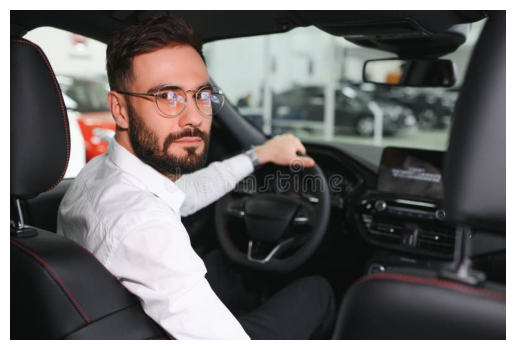

In [138]:
import requests
from PIL import Image

url = 'https://thumbs.dreamstime.com/b/transportation-vehicle-people-concept-male-car-driver-looking-passenger-back-seat-273571683.jpg'

filename = "driver_test.jpg"

response = requests.get(url)
with open(filename, "wb") as f:
    f.write(response.content)

img = Image.open("driver_test.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [139]:
from tensorflow.keras.preprocessing import image

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0          # normalize
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
    return img_array

img_path = "driver_test.jpg"

processed_img = preprocess_image(img_path)


### VGG model prediction

In [140]:
#VGG_model predictions
prediction_vgg = vgg_model.predict(processed_img)
print("Raw prediction:", prediction_vgg)

predicted_class = np.argmax(prediction_vgg)
confidence = np.max(prediction_vgg)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Raw prediction: [[0.20298326 0.18125166 0.23855785 0.17425211 0.20295507]]
Predicted Class: talking_phone
Confidence: 0.23855785


### Mobilenet model prediction

In [141]:
#mobilenet_model predictions
prediction_mobile = mobilenet_model.predict(processed_img)
print("Raw prediction:", prediction_mobile)

predicted_class = np.argmax(prediction_mobile)
confidence = np.max(prediction_mobile)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Raw prediction: [[1.58445939e-01 1.15399125e-05 2.10064650e-06 1.17847330e-05
  8.41528594e-01]]
Predicted Class: turning
Confidence: 0.8415286


### Alex_model prediction

In [142]:
#Alex_model predictions
prediction_alex = model_Alex.predict(processed_img)

print("Raw prediction:", prediction_alex)

predicted_class = np.argmax(prediction_alex)
confidence = np.max(prediction_alex)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Raw prediction: [[9.9993467e-01 2.1202798e-06 3.9887276e-05 1.0036863e-06 2.2316599e-05]]
Predicted Class: other_activities
Confidence: 0.9999347


**Results**

* VGG16 and AlexNet models misclassified this image.

* MobileNet is able to classify correctly.

## Testing on Another Image

* Ckeck for the different another image.

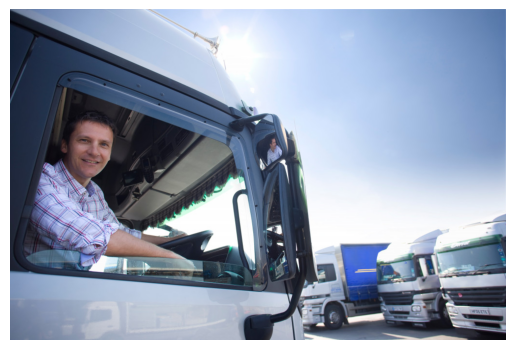

In [133]:
url = 'https://youngpeopletoday.net/wp-content/uploads/2022/11/images3937-637b7d9d5d65d.jpg'

img = "car_driver.jpg"

response = requests.get(url)
with open(img, "wb") as f:
    f.write(response.content)

img = Image.open("car_driver.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

### VGG model prediction

In [134]:
img='car_driver.jpg'
processed_img = preprocess_image(img)

vgg_prediction = vgg_model.predict(processed_img)

print("Raw prediction:", vgg_prediction)

predicted_class = np.argmax(vgg_prediction)
confidence = np.max(vgg_prediction)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Raw prediction: [[0.18128857 0.19522017 0.21958415 0.20711303 0.19679408]]
Predicted Class: talking_phone
Confidence: 0.21958415


### MobileNet model prediction

In [135]:
mobile_prediction = mobilenet_model.predict(processed_img)

print("Raw prediction:", mobile_prediction)

predicted_class = np.argmax(mobile_prediction)
confidence = np.max(mobile_prediction)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Raw prediction: [[0.03473032 0.08234456 0.00368742 0.00263031 0.8766074 ]]
Predicted Class: turning
Confidence: 0.8766074


### Alex model prediction

In [136]:
alex_prediction = model_Alex.predict(processed_img)

print("Raw prediction:", alex_prediction)

predicted_class = np.argmax(alex_prediction)
confidence = np.max(alex_prediction)

print("Predicted Class:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Raw prediction: [[0.1781103  0.04447179 0.02143126 0.01014111 0.7458455 ]]
Predicted Class: turning
Confidence: 0.7458455


**Result**

* VGG16 model misclassified the image.

* AlexNet and MobileNet models are able to classify the image correctly.

* VGG16 model seems like overfitted(learned dataset very much) and finding difficulty to classify a new image .

## Conclusion

* This experiment demonstrates that transfer learning substantially improves
image classification performance compared to training a CNN from scratch.

* Pretrained models such as VGG16 and MobileNetV2, AlexNet leverage learned representations
from large-scale datasets (ImageNet), enabling better generalization.

* Among them, VGG16 achieved the highest accuracy, demonstrating superior feature extraction capability and classification performance on the given dataset.

* However, testing on completely new external images revealed some performance variation. This highlights the importance of dataset diversity and real-world variability in improving generalization.

* Future improvements may include stronger data augmentation and expanding the dataset with more diverse driving conditions.

* Overall, this project demonstrates that deep learning techniques can effectively classify driver behaviors and can serve as a foundation for real-time Driver Monitoring Systems. Such systems have significant potential to reduce road accidents by detecting and alerting unsafe driving activities